In [ ]:
import re
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

comments_path = "/kaggle/input/datasets/comments.txt"

def parse_comments(filepath):
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = [line.strip() for line in f if line.strip()]

    comments = []
    time_pattern = re.compile(r".*(second|minute|hour|day|week|month|year)s?\s+ago.*", re.IGNORECASE)

    i = 0
    while i < len(lines) - 1:
        if time_pattern.match(lines[i + 1]):
            username = lines[i]
            timestamp = lines[i + 1]
            i += 2
            comment_text = []

            while i < len(lines) and not (i + 1 < len(lines) and time_pattern.match(lines[i + 1])):
                current_line = lines[i]
                low = current_line.lower()
                if low not in {"reply", "...more"} and not re.fullmatch(r"[\d,.KMk]+", current_line) and not low.startswith("show more replies"):
                    comment_text.append(current_line)
                i += 1

            if comment_text:
                comments.append(
                    {
                        "username": username,
                        "timestamp_text": timestamp,
                        "comment_text": " ".join(comment_text),
                    }
                )
        else:
            i += 1

    return pd.DataFrame(comments)

extra_stop = {
    "reply","replies","video","videos","just","like","dont","didnt","doesnt",
    "im","ive","youre","thats","isnt","cant","yeah","lol","omg","www","https",
    "said","say","thing","things","really","make","makes","look","looking",
    "watching","watch","watched","kurzgesagt","channel","got","did","does","isn",
    "don","shouldn","couldn","wouldn","wasn","weren","aint","gonna"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = text.replace("’", "'").replace("`", "'")
    text = text.replace("don't", "do not").replace("doesn't", "does not").replace("can't", "can not")
    text = text.replace("isn't", "is not").replace("i'm", "i am").replace("you're", "you are")
    words = re.findall(r"[a-z]{3,}", text)
    return [w for w in words if w not in ENGLISH_STOP_WORDS and w not in extra_stop]

raw_df = parse_comments(comments_path)
raw_df["cleaned_tokens"] = raw_df["comment_text"].apply(clean_text)
raw_df["processed_text"] = raw_df["cleaned_tokens"].apply(lambda x: " ".join(x))
analysis_df = raw_df[raw_df["processed_text"].str.strip() != ""].copy().reset_index(drop=True)

print("Number of usable comments:", len(analysis_df))
print("Text field used:", "processed_text")
print("Sample processed comment text:")
print(analysis_df.loc[0, "processed_text"])


Number of usable comments: 734
Text field used: processed_text
Sample processed comment text:
feeling lonely sky pick direction wave universe infinite means feeling lonely waving directly


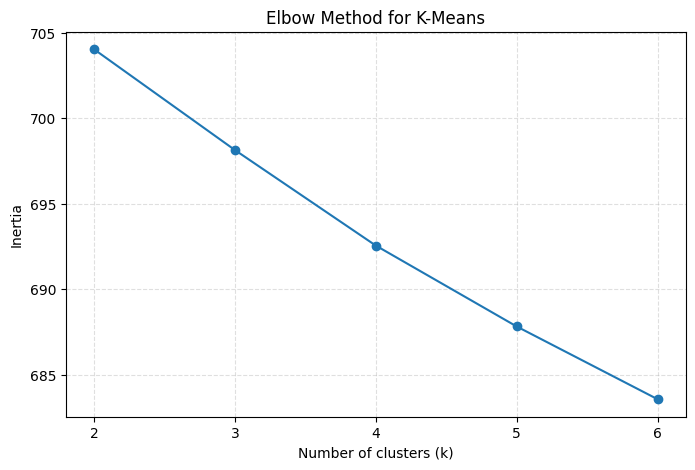

,k,inertia
0,2,704.039140
1,3,698.141827
2,4,692.550981
3,5,687.816967
4,6,683.560085


Chosen k = 4


In [3]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

vectorizer = TfidfVectorizer(max_features=1500)
X = vectorizer.fit_transform(analysis_df["processed_text"])

k_values = list(range(2, 7))
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

elbow_df = pd.DataFrame({"k": k_values, "inertia": inertias})
display(elbow_df)

best_k = 4
print("Chosen k =", best_k)


In [4]:
import numpy as np
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
analysis_df["cluster"] = kmeans.fit_predict(X)

terms = np.array(vectorizer.get_feature_names_out())

for cluster_id in range(best_k):
    cluster_size = int((analysis_df["cluster"] == cluster_id).sum())
    center = kmeans.cluster_centers_[cluster_id]
    top_terms = terms[center.argsort()[::-1][:5]].tolist()

    print(f"Cluster {cluster_id}")
    print("Number of comments:", cluster_size)
    print("Top 5 representative terms:", ", ".join(top_terms))
    print()


Cluster 0
Number of comments: 182
Top 5 representative terms: universe, space, time, big, edge

Cluster 1
Number of comments: 100
Top 5 representative terms: infinite, universe, finite, matter, think

Cluster 2
Number of comments: 36
Top 5 representative terms: know, universe, think, beginning, little

Cluster 3
Number of comments: 416
Top 5 representative terms: brain, end, light, love, infinity



sentiment,positive,neutral,negative
cluster,,,
0,48,116,18
1,32,53,15
2,13,17,6
3,174,193,49


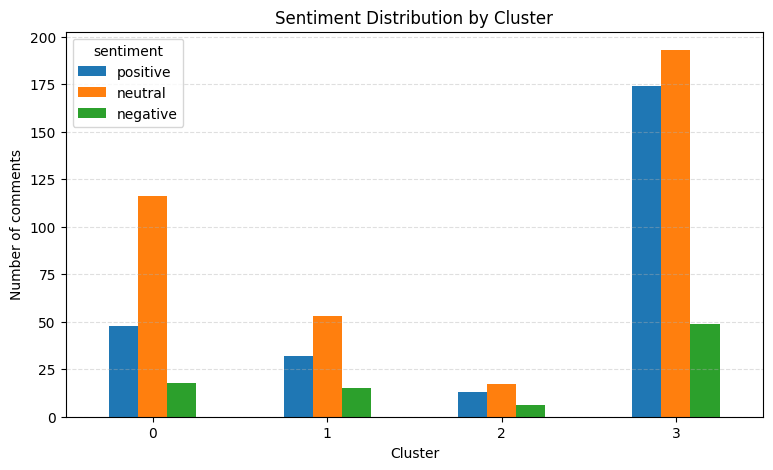

In [5]:
import subprocess
import sys

try:
    from textblob import TextBlob
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "textblob", "-q"])
    from textblob import TextBlob

def get_sentiment_label(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.1:
        return "positive"
    if polarity < -0.1:
        return "negative"
    return "neutral"

analysis_df["sentiment"] = analysis_df["comment_text"].apply(get_sentiment_label)

sentiment_table = pd.crosstab(analysis_df["cluster"], analysis_df["sentiment"]).reindex(
    columns=["positive", "neutral", "negative"],
    fill_value=0
)

display(sentiment_table)

ax = sentiment_table.plot(kind="bar", figsize=(9, 5))
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of comments")
ax.set_title("Sentiment Distribution by Cluster")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


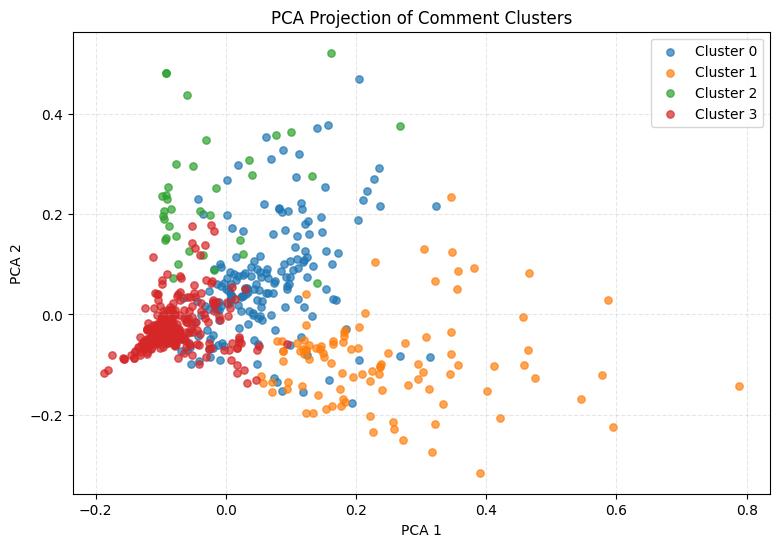

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray())

plot_df = pd.DataFrame(
    {
        "pca1": X_2d[:, 0],
        "pca2": X_2d[:, 1],
        "cluster": analysis_df["cluster"]
    }
)

plt.figure(figsize=(9, 6))
for cluster_id in sorted(plot_df["cluster"].unique()):
    subset = plot_df[plot_df["cluster"] == cluster_id]
    plt.scatter(subset["pca1"], subset["pca2"], s=28, alpha=0.7, label=f"Cluster {cluster_id}")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Projection of Comment Clusters")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()
